In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_CPP_MIN_VLOG_LEVEL"] = "3"

import h5py
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import tensorflow as tf
import keras
from keras.layers import *
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize, StandardScaler
from keras.utils import Progbar

file_q = h5py.File("datasets/q.hdf5", 'r')  # background jets
file_g = h5py.File("datasets/g.hdf5", 'r')  # background jets
file_w = h5py.File("datasets/w.hdf5", 'r')  # signal jets
file_z = h5py.File("datasets/z.hdf5", 'r')
file_t = h5py.File("datasets/t.hdf5", 'r')

x_q = file_q['particle_features'][:]
x_g = file_g['particle_features'][:]
x_w = file_w['particle_features'][:]
x_z = file_z['particle_features'][:]
x_t = file_t['particle_features'][:]

y_q = np.tile([1,0,0,0,0], (x_q.shape[0], 1))
y_g = np.tile([0,1,0,0,0], (x_g.shape[0], 1))
y_w = np.tile([0,0,1,0,0], (x_w.shape[0], 1))
y_z = np.tile([0,0,0,1,0], (x_z.shape[0], 1))
y_t = np.tile([0,0,0,0,1], (x_t.shape[0], 1))

# Cap q/g to a fixed, class-balanced total so all splits are deterministic
QG_TOTAL = 340000
per_class = QG_TOTAL // 2
assert per_class <= min(len(x_q), len(x_g)), \
    f"QG_TOTAL={QG_TOTAL} too large; have q={len(x_q)}, g={len(x_g)}"
x_q = x_q[:per_class]; y_q = y_q[:per_class]
x_g = x_g[:per_class]; y_g = y_g[:per_class]

# IMPORTANT: split q/g into pretrain (80%) and held-out (20%) BEFORE use
# Test q/g must come from the held-out 20% so pretraining never saw them.
# q+g pool, shuffled with a fixed seed so JEPA and LeJEPA notebooks see
# EXACTLY the same split (required for a fair comparison).
x_qg = np.concatenate([x_q, x_g], axis=0)
y_qg = np.concatenate([y_q, y_g], axis=0)

rng_qg = np.random.default_rng(43)
perm_qg = rng_qg.permutation(len(x_qg))
x_qg = x_qg[perm_qg]
y_qg = y_qg[perm_qg]

QG_HOLDOUT_FRAC = 0.20
n_qg          = len(x_qg)
n_qg_holdout  = int(n_qg * QG_HOLDOUT_FRAC)
n_qg_pretrain = n_qg - n_qg_holdout

# the 80% that pretraining is allowed to see
x_qg_pretrain = x_qg[:n_qg_pretrain]
y_qg_pretrain = y_qg[:n_qg_pretrain]

# the 20% held out — only for downstream testing
x_qg_heldout  = x_qg[n_qg_pretrain:]
y_qg_heldout  = y_qg[n_qg_pretrain:]

# ----- pretraining train/val come from the pretrain pool only -----
TRAIN_SIZE = 250000   # set to a smaller number to downsample training
n_val      = 10000

assert TRAIN_SIZE + n_val <= n_qg_pretrain, \
    f"TRAIN_SIZE + n_val = {TRAIN_SIZE + n_val} exceeds pretrain pool {n_qg_pretrain}"

x_train = x_qg_pretrain[:TRAIN_SIZE]
y_train = y_qg_pretrain[:TRAIN_SIZE]

x_val   = x_qg_pretrain[TRAIN_SIZE:TRAIN_SIZE + n_val]
y_val   = y_qg_pretrain[TRAIN_SIZE:TRAIN_SIZE + n_val]

# ----- test pool: held-out q/g + ALL W/Z/t (none of W/Z/t was in pretraining) -----
x_test_pool = np.concatenate([x_qg_heldout, x_w, x_z, x_t], axis=0)
y_test_pool = np.concatenate([y_qg_heldout, y_w, y_z, y_t], axis=0)

rng_test = np.random.default_rng(42)
perm_test = rng_test.permutation(len(x_test_pool))
x_test_pool = x_test_pool[perm_test]
y_test_pool = y_test_pool[perm_test]

n_test = min(100000, len(x_test_pool))
x_test = x_test_pool[:n_test]
y_test = y_test_pool[:n_test]

# ----- sanity prints -----
print("TRAIN_SIZE:", TRAIN_SIZE)
print("x_train shape:", x_train.shape)
print("x_val   shape:", x_val.shape)
print("x_test  shape:", x_test.shape)
print()
print(f"q/g total: {n_qg}")
print(f"  pretrain pool: {n_qg_pretrain}  (seen by SSL)")
print(f"  held-out:      {n_qg_holdout}  (test-only; never seen by SSL)")
print(f"W:  {len(x_w)},  Z: {len(x_z)},  t: {len(x_t)}  (all test-only)")
print()
print("Test class counts [q, g, W, Z, t]:",
      np.bincount(np.argmax(y_test, axis=1), minlength=5))

# ----- leakage sanity check: confirm no train-jet appears in test -----
# Hash a sample of train jets and a sample of test q/g jets; overlap MUST be 0
# (or at most a handful from duplicate jets that exist in the dataset itself).
train_fps  = {hash(x_train[i].tobytes()) for i in range(0, len(x_train), 200)}
test_qg_idx = np.where(np.argmax(y_test, axis=1) < 2)[0][:5000]
test_qg_fps = {hash(x_test[i].tobytes()) for i in test_qg_idx}
overlap = len(train_fps & test_qg_fps)
print(f"\nLeakage check (sampled): overlap train vs test-q/g = {overlap}")
if overlap > 0:
    print(f"  (note: {overlap} overlaps likely due to duplicate jets in the dataset itself, not leakage)")
assert overlap <= 20, "LEAKAGE DETECTED — pretraining and test q/g jets overlap!"

del x_qg, y_qg, x_qg_pretrain, y_qg_pretrain, x_test_pool, y_test_pool

TRAIN_SIZE: 250000
x_train shape: (250000, 30, 4)
x_val   shape: (10000, 30, 4)
x_test  shape: (100000, 30, 4)

q/g total: 340000
  pretrain pool: 272000  (seen by SSL)
  held-out:      68000  (test-only; never seen by SSL)
W:  177172,  Z: 176952,  t: 177945  (all test-only)

Test class counts [q, g, W, Z, t]: [ 5648  5661 29363 29467 29861]

Leakage check (sampled): overlap train vs test-q/g = 0


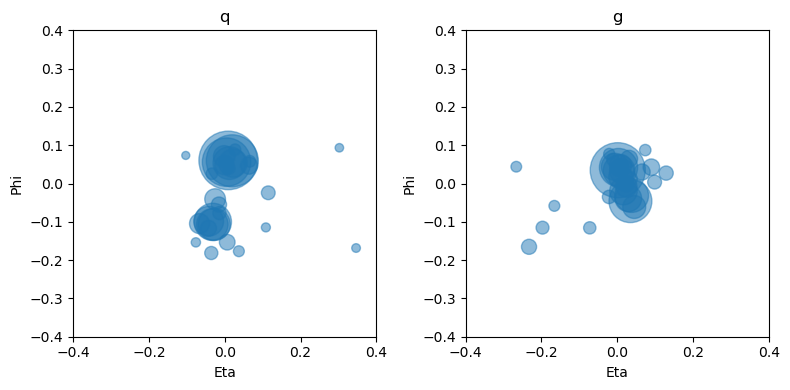

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
class_names = ['q', 'g']

for i, class_name in enumerate(class_names):
    class_idx = np.where(y_train.argmax(axis=1)==i)[0][0]
    jet = x_train[class_idx]
    eta = jet[:,0]
    phi = jet[:,1]
    pt = jet[:,2]
    mask = jet[:,3]
    
    eta = eta[mask==1]
    phi = phi[mask==1]
    pt = pt[mask==1]
    size = pt*10000

    axs[i].scatter(eta, phi, color='C0', s=size, alpha=0.5)
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Phi")
    axs[i].set_title(class_name)
    axs[i].set_xlim(-0.4, 0.4)
    axs[i].set_ylim(-0.4, 0.4)

plt.tight_layout()
plt.show()

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import math
import numpy as np

# ===== Hyperparameters =====
BATCH = 1024
D_MODEL = 128
DEPTH   = 4
HEADS   = 8
DROPOUT = 0.10
EMA_M   = 0.996

MASK_PROB = 1.0

MASK_RATIO_RANGE = (0.40, 0.60)

def make_pos(eta, phi):
    return np.stack([
        eta, np.sin(phi), np.cos(phi),
        np.sin(eta), np.cos(eta)
    ], axis=-1).astype(np.float32)

def make_attn_mask_from_valid(valid_q, valid_k):
    q = tf.cast(tf.expand_dims(valid_q, 2), tf.bool)
    k = tf.cast(tf.expand_dims(valid_k, 1), tf.bool)
    return tf.logical_and(q, k)

def masked_pt_fraction(pt, valid, target_mask, eps=1e-9):
    pt = np.asarray(pt, dtype=np.float32)
    v  = np.asarray(valid, dtype=np.float32)
    tm = np.asarray(target_mask, dtype=np.float32)
    total_pt  = np.sum(pt * v, axis=1) + eps
    masked_pt = np.sum(pt * v * tm, axis=1)
    return masked_pt / total_pt

def summarize(frac, name=""):
    frac = np.asarray(frac, dtype=np.float32)
    print(f"\n[{name}] masked pT fraction stats (per jet)")
    print("  mean   :", float(np.mean(frac)))
    print("  std    :", float(np.std(frac)))
    print("  median :", float(np.median(frac)))
    for p in [5, 10, 25, 50, 75, 90, 95]:
        print(f"  p{p:02d}    :", float(np.percentile(frac, p)))

@tf.function
def sample_target_mask_pt_ratio(jets, p_mask=1.0, ratio_range=(0.30, 0.40)):
    """
    jBOT-style particle-level masking:
      - sample target masked-pT fraction
      - random permutation over valid particles
      - choose prefix whose cumulative pT is closest to target
    jets: (B, N, 4) = [eta, phi, pt, valid]
    return: (B, N) bool
    """
    jets = tf.cast(jets, tf.float32)
    pt = jets[..., 2]
    valid = jets[..., 3] > 0.5
    pt = tf.where(valid, pt, 0.0)

    B = tf.shape(jets)[0]

    p_mask = tf.cast(p_mask, tf.float32)
    rmin = tf.cast(ratio_range[0], tf.float32)
    rmax = tf.cast(ratio_range[1], tf.float32)

    # For each jet, sample a Bernoulli variable:
    # do_mask[b] = True with probability p_mask
    do_mask = tf.random.uniform([B]) < p_mask
    r = tf.where(do_mask, tf.random.uniform([B], rmin, rmax), 0.0)  # (B,)

    #Compute target masked pT amount per jet
    total_pt = tf.reduce_sum(pt, axis=-1)   # (B,)
    target = r * total_pt                   # (B,) desired masked pT per jet

    # random permutation among valid particles
    keys = tf.random.uniform(tf.shape(pt))
    keys = tf.where(valid, keys, 2.0)       # invalid pushed to end
    order = tf.argsort(keys, axis=-1)

    pt_perm = tf.gather(pt, order, batch_dims=1)   # (B,N)
    csum = tf.cumsum(pt_perm, axis=-1)             # (B,N)

    #Find where cumulative pT first reaches target
    hit = csum >= target[:, None]
    any_hit = tf.reduce_any(hit, axis=-1)
    k_first = tf.argmax(tf.cast(hit, tf.int32), axis=-1, output_type=tf.int32)

    n_valid = tf.reduce_sum(tf.cast(valid, tf.int32), axis=-1)
    last_valid = n_valid - 1
    k = tf.where(any_hit, k_first, last_valid)

    b = tf.range(B)
    curr_sum = tf.gather_nd(csum, tf.stack([b, k], axis=1))

    k_prev = tf.maximum(k - 1, 0)
    prev_sum_raw = tf.gather_nd(csum, tf.stack([b, k_prev], axis=1))
    prev_sum = tf.where(k > 0, prev_sum_raw, 0.0)

    #Choose whichever is closer to the target:
    #taking k+1 particles or taking only k particles
    use_curr = tf.abs(curr_sum - target) <= tf.abs(prev_sum - target)
    n_take = tf.where(use_curr, k + 1, k)

    # enforce at least 1 masked and at least 1 unmasked when masking is on
    n_take = tf.maximum(n_take, 1)
    n_take = tf.minimum(n_take, tf.maximum(n_valid - 4, 1))
    n_take = tf.where(r > 0.0, n_take, 0)

    mask_sorted = tf.sequence_mask(n_take, maxlen=tf.shape(jets)[1])  # (B,N)
    inv = tf.argsort(order, axis=-1)
    mask = tf.gather(mask_sorted, inv, batch_dims=1)

    return tf.cast(mask, tf.float32)

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

class TransformerEncoderBlock(layers.Layer):
    """Pre-norm Transformer encoder block with MHA and MLP."""
    def __init__(self, d_model, num_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout,
        )
        self.drop1 = layers.Dropout(dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp   = keras.Sequential([
            layers.Dense(d_model * mlp_ratio, activation=layers.Activation("gelu")),
            layers.Dropout(dropout),
            layers.Dense(d_model),
        ])
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, attn_mask=None, training=False):
        # Self-attention with optional (B, Tq, Tk) boolean attention mask
        y = self.attn(self.norm1(x), self.norm1(x),
                      attention_mask=attn_mask,
                      training=training)
        x = x + self.drop1(y, training=training)
        z = self.mlp(self.norm2(x), training=training)
        x = x + self.drop2(z, training=training)
        return x


class ParticleEncoder(keras.Model):
    """
    Subjet/Cell Transformer encoder.
    Inputs:
      x_tokens: (B, N, F) float — per-cell features
      valid_mask: (B, N) {0,1}  — 1 for real cells, 0 for padding
    Output:
      (B, N, D) — per-cell embeddings with padding zeroed out
    """
    def __init__(self, d_model, depth, heads, dropout=0.0, name=None):
        super().__init__(name=name)
        # Nonlinear token embedding (works well with mixed stats like sum_pT, counts, etc.)
        self.token_embed = keras.Sequential([
            layers.Dense(d_model, activation=layers.Activation("gelu")),
            layers.Dense(d_model),
        ])
        self.blocks = [
            TransformerEncoderBlock(d_model, heads, mlp_ratio=4, dropout=dropout)
            for _ in range(depth)
        ]
        self.norm = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x_tokens, valid_mask, training=False):
        x = self.token_embed(x_tokens, training=training)  # (B,N,D)

        # Attention mask: True=keep, False=mask. We block attention to padded keys.
        attn_mask = tf.logical_and(
            tf.cast(tf.expand_dims(valid_mask, 2), tf.bool),
            tf.cast(tf.expand_dims(valid_mask, 1), tf.bool),
        )  # (B,N,N)

        for blk in self.blocks:
            x = blk(x, attn_mask=attn_mask, training=training)
        x = self.norm(x, training=training)

        # Zero-out padded positions to avoid leakage downstream
        x = x * tf.expand_dims(tf.cast(valid_mask, x.dtype), -1)
        return x


class Predictor(keras.Model):
    """
    Cross-attention predictor:
      - Query = positional embedding for *all* cells (we supervise only targets later)
      - Key/Value = context embeddings
    Returns per-cell predicted embeddings, (B, N, D)
    """
    def __init__(self, d_model, depth, heads, dropout=0.0, name=None):
        super().__init__(name=name)
        self.pos_embed = keras.Sequential([
            layers.Dense(d_model, activation=layers.Activation("gelu")),
            layers.Dense(d_model),
        ])
        # A few light self-attention layers after cross-attention act as a bottleneck
        self.blocks = [
            TransformerEncoderBlock(d_model, heads, mlp_ratio=4, dropout=dropout)
            for _ in range(max(1, depth // 2))
        ]
        self.cross_attn = layers.MultiHeadAttention(
            num_heads=heads, key_dim=d_model // heads, dropout=dropout
        )
        self.norm_q = layers.LayerNormalization(epsilon=1e-6)
        self.norm_kv = layers.LayerNormalization(epsilon=1e-6)
        self.proj = layers.Dense(d_model)

    def call(self, context_repr, context_valid, all_pos, all_valid, training=False):
        q = self.pos_embed(all_pos, training=training)
    
        kv_mask = tf.logical_and(
            tf.cast(tf.expand_dims(all_valid, 2), tf.bool),     # real queries only
            tf.cast(tf.expand_dims(context_valid, 1), tf.bool)  # context keys only
        )
    
        # Pre-norm cross-attention WITH residual.
        # Q comes from positional embedding; K/V come from student context repr.
        # Both sides are LayerNorm'd before attention (pre-norm style),
        # and the attention output is added back to q as a residual so the
        # predictor cannot bypass the student.
        q_n  = self.norm_q(q)
        kv_n = self.norm_kv(context_repr)
        attn_out = self.cross_attn(
            q_n, kv_n,
            attention_mask=kv_mask,
            training=training,
        )
        x = q_n + attn_out  # <-- residual: forces predictor to use student output
    
        full_attn_mask = tf.logical_and(
            tf.cast(tf.expand_dims(all_valid, 2), tf.bool),
            tf.cast(tf.expand_dims(all_valid, 1), tf.bool),
        )
    
        for blk in self.blocks:
            x = blk(x, attn_mask=full_attn_mask, training=training)
    
        out = self.proj(x, training=training)
        out = out * tf.expand_dims(tf.cast(all_valid, out.dtype), -1)
        return out


In [6]:
class CellJEPA(keras.Model):
    """
    JEPA with particle-level target masking.
    Student = context encoder; Teacher = target encoder (EMA-updated).
    Predictor maps context representations + positional hints -> target representations.
    """

    def __init__(self, d_model=128, depth=4, heads=8, dropout=0.1,
                 ema_momentum=0.996, **kwargs):
        super().__init__(**kwargs)

        self.student   = ParticleEncoder(d_model, depth, heads, dropout, name="student")
        self.teacher   = ParticleEncoder(d_model, depth, heads, dropout, name="teacher")
        self.predictor = Predictor(d_model, depth, heads, dropout, name="predictor")

        self.ema_m = float(ema_momentum)

        DUMMY_N = 30
        DUMMY_F = 3

        dummy_x = tf.zeros([1, DUMMY_N, DUMMY_F], dtype=tf.float32)
        dummy_v = tf.ones([1, DUMMY_N], dtype=tf.float32)
        dummy_p = tf.zeros([1, DUMMY_N, 5], dtype=tf.float32)
        dummy_z = tf.zeros([1, DUMMY_N, d_model], dtype=tf.float32)

        _ = self.student(dummy_x, dummy_v, training=False)
        _ = self.teacher(dummy_x, dummy_v, training=False)
        _ = self.predictor(
            context_repr=dummy_z,
            context_valid=dummy_v,
            all_pos=dummy_p,
            all_valid=dummy_v,
            training=False,
        )

        self._copy_student_to_teacher(initial=True)

        self.loss_tracker = keras.metrics.Mean(name="loss")

    def _copy_student_to_teacher(self, initial=False):
        s_vars = self.student.weights
        t_vars = self.teacher.weights
        assert len(s_vars) == len(t_vars), \
            f"student/teacher weight count mismatch: {len(s_vars)} vs {len(t_vars)}"
        for sv, tv in zip(s_vars, t_vars):
            if initial:
                tv.assign(sv)
            else:
                tv.assign(self.ema_m * tv + (1.0 - self.ema_m) * sv)

    def _ssl_forward(self, x_feats, pos, valid, target_mask, training):
        """
        x_feats:     (B, N, F)
        pos:         (B, N, 2)
        valid:       (B, N) float {0,1}
        target_mask: (B, N) float {0,1}
        """
        # target must be valid
        target_mask = target_mask * valid

        # context = valid but not target
        context_mask = valid * (1.0 - target_mask)

        z_s = self.student(x_feats, context_mask, training=training)
        z_t = tf.stop_gradient(self.teacher(x_feats, valid, training=False))

        # representation-space masking
        context_repr = z_s

        # predictor queries target positions only
        z_pred = self.predictor(
            context_repr=context_repr,
            context_valid=context_mask,
            all_pos=pos,
            all_valid=target_mask,
            training=training,
        )

        diff = (z_pred - z_t) * tf.expand_dims(target_mask, -1)
        denom = tf.reduce_sum(target_mask) * tf.cast(tf.shape(z_s)[-1], tf.float32) + 1e-9
        loss = tf.reduce_sum(tf.square(diff)) / denom
        return loss

    def train_step(self, data):
        """
        Expects:
          (x_feats, pos, valid, target_mask)
        """
        x_feats, pos, valid, target_mask = data

        with tf.GradientTape() as tape:
            loss = self._ssl_forward(
                x_feats, pos, valid, target_mask, training=True
            )

        train_vars = self.student.trainable_variables + self.predictor.trainable_variables
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))

        self._copy_student_to_teacher(initial=False)

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        """
        Expects:
          (x_feats, pos, valid, target_mask)
        """
        x_feats, pos, valid, target_mask = data

        loss = self._ssl_forward(
            x_feats, pos, valid, target_mask, training=False
        )

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def get_teacher_and_pred(self, x_feats, pos, valid, target_mask, batch_size=256):
        zt_list = []
        zp_list = []

        N = x_feats.shape[0]
        for i in range(0, N, batch_size):
            xb = tf.convert_to_tensor(x_feats[i:i+batch_size], dtype=tf.float32)
            pb = tf.convert_to_tensor(pos[i:i+batch_size], dtype=tf.float32)
            vb = tf.convert_to_tensor(valid[i:i+batch_size], dtype=tf.float32)
            tb = tf.convert_to_tensor(target_mask[i:i+batch_size], dtype=tf.float32)

            z_t = self.teacher(xb, vb, training=False)

            z_s = self.student(xb, vb, training=False)
            context_mask = vb * (1.0 - tb)
            context_repr = z_s * tf.expand_dims(context_mask, -1)

            z_pred = self.predictor(
                context_repr=context_repr,
                context_valid=context_mask,
                all_pos=pb,
                all_valid=tb,
                training=False,
            )

            zt_list.append(z_t.numpy())
            zp_list.append(z_pred.numpy())

        return np.concatenate(zt_list, axis=0), np.concatenate(zp_list, axis=0)

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, inputs, training=False):
        """
        Accepts:
          (x_feats, pos, valid)
        """
        if isinstance(inputs, (list, tuple)) and len(inputs) == 3:
            x_feats, pos, valid = inputs
        else:
            raise ValueError("CellJEPA.call expects (x_feats, pos, valid)")
        return self.student(x_feats, valid, training=training)

In [7]:
# ----- Build particle-level features from x_* -----
# x_* shape: (B, 30, 4) with [eta, phi, pT, valid]

def make_particle_features(x):
    eta   = x[..., 0]
    phi   = x[..., 1]
    pt    = x[..., 2]
    valid = x[..., 3]

    feats = np.stack(
        [eta, phi, np.log1p(np.maximum(pt, 0.0))],
        axis=-1
    ).astype(np.float32)

    return feats, eta.astype(np.float32), phi.astype(np.float32), valid.astype(np.float32)

part_feats_train, eta_train, phi_train, valid_train = make_particle_features(x_train)
part_feats_val,   eta_val,   phi_val,   valid_val   = make_particle_features(x_val)
part_feats_test,  eta_test,  phi_test,  valid_test  = make_particle_features(x_test)

pos_train = make_pos(eta_train, phi_train)
pos_val   = make_pos(eta_val,   phi_val)
pos_test  = make_pos(eta_test,  phi_test)

def make_ssl_dataset_quartet(
    x_feats,
    pos,
    valid,
    target_mask,
    batch_size=BATCH,
    shuffle=True,
    repeat=False,
):
    x_feats = tf.convert_to_tensor(x_feats, dtype=tf.float32)
    pos = tf.convert_to_tensor(pos, dtype=tf.float32)
    valid = tf.convert_to_tensor(valid, dtype=tf.float32)
    target_mask = tf.convert_to_tensor(target_mask, dtype=tf.float32)

    ds = tf.data.Dataset.from_tensor_slices(
        (x_feats, pos, valid, target_mask)
    )

    if shuffle:
        ds = ds.shuffle(10000, seed=42, reshuffle_each_iteration=True)
    if repeat:
        ds = ds.repeat()

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# fixed val target mask from raw particles (jBOT-style)
target_mask_val = sample_target_mask_pt_ratio(
    tf.convert_to_tensor(x_val, tf.float32),
    p_mask=MASK_PROB,
    ratio_range=MASK_RATIO_RANGE,
).numpy().astype(np.float32)

ssl_val = make_ssl_dataset_quartet(
    part_feats_val,
    pos_val,
    valid_val,
    target_mask_val,
    repeat=False,
    shuffle=False,
)

EPOCHS = 100
BASE_LR = 5e-4
warmup_epochs = int(0.10 * EPOCHS)

def lr_fn(epoch):
    if epoch < warmup_epochs:
        return BASE_LR * float(epoch + 1) / float(max(1, warmup_epochs))
    progress = (epoch - warmup_epochs) / float(max(1, EPOCHS - warmup_epochs))
    return BASE_LR * 0.5 * (1.0 + np.cos(np.pi * progress))

lr_sched = tf.keras.callbacks.LearningRateScheduler(lr_fn, verbose=1)

optimizer = keras.optimizers.AdamW(
    learning_rate=BASE_LR,
    weight_decay=3e-3
)

jepa = CellJEPA(
    d_model=D_MODEL,
    depth=DEPTH,
    heads=HEADS,
    dropout=DROPOUT,
)
jepa.compile(optimizer=optimizer)

2026-04-14 16:07:45.124513: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 848 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


In [8]:
# --- Build the graph so summary() shows concrete shapes
B_dummy = 1
N_max   = part_feats_train.shape[1]   # number of particles (e.g. 30)
F       = part_feats_train.shape[2]   # feature dim (should be 3: [eta, phi, log1p(pt)])


print("\n=== ParticleJEPA (top-level) ===")
#jepa.summary(expand_nested=True, show_trainable=True)

# --- Student / Teacher encoders as functional wrappers
D = D_MODEL

feats_in = keras.Input(shape=(N_max, F), name="particle_feats")
mask_in  = keras.Input(shape=(N_max,),   name="valid_mask")
stu_out  = jepa.student(feats_in, mask_in)
tea_out  = jepa.teacher(feats_in, mask_in)

student_model = keras.Model([feats_in, mask_in], stu_out, name="StudentEncoder")
teacher_model = keras.Model([feats_in, mask_in], tea_out, name="TeacherEncoder")

print("\n=== Student encoder ===")
student_model.summary(expand_nested=True, show_trainable=True)

print("\n=== Teacher encoder (EMA/frozen at runtime) ===")
teacher_model.summary(expand_nested=True, show_trainable=True)

# --- Predictor wrapper (pos-MLP + cross-attn + MLP)
# --- Predictor wrapper (uses jepa.predictor weights)
# --- Predictor: avoid summary() (can fail due to symbolic mask shape inference) ---
print("\n=== Predictor (jepa.predictor) ===")

ctx   = tf.zeros((B_dummy, N_max, D), dtype=tf.float32)
ctx_v = tf.ones((B_dummy, N_max),     dtype=tf.float32)   # context-valid mask
pos   = tf.zeros((B_dummy, N_max, 5), dtype=tf.float32)
all_v = tf.ones((B_dummy, N_max),     dtype=tf.float32)   # overall valid mask

out = jepa.predictor(ctx, ctx_v, pos, all_v, training=False)
print("Predictor output shape:", out.shape)
print("Predictor params:", jepa.predictor.count_params())


=== ParticleJEPA (top-level) ===

=== Student encoder ===


Model: "StudentEncoder"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ particle_feats    │ (None, 30, 3)   │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ valid_mask        │ (None, 30)      │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ student           │ (None, 30, 128) │   810,368 │ particle_feat… │   Y   │
│ (ParticleEncoder) │                 │           │ valid_mask[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └ sequential   │ (1, 30, 128)    │    17,024 │ -              │   Y   │
│ (Sequential)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│       └ dense     │ (1, 30, 128)    │       512 │ -              │   Y   │
│ (Dense)           │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│       └ dense_1   │ (1, 30, 128)    │    16,512 │ -              │   Y   │
│ (Dense)           │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ (1, 30, 128)    │       256 │ -              │   Y   │
│ layer_normalizat… │                 │           │                │       │
│ (LayerNormalizat… │                 │           │                │       │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 810,368 (3.09 MB)

 Trainable params: 810,368 (3.09 MB)

...

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ particle_feats    │ (None, 30, 3)   │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ valid_mask        │ (None, 30)      │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ teacher           │ (None, 30, 128) │   810,368 │ particle_feat… │   Y   │
│ (ParticleEncoder) │                 │           │ valid_mask[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └ sequential_5 │ (1, 30, 128)    │    17,024 │ -              │   Y   │
│ (Sequential)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│       └ dense_10  │ (1, 30, 128)    │       512 │ -              │   Y   │
│ (Dense)           │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│       └ dense_11  │ (1, 30, 128)    │    16,512 │ -              │   Y   │
│ (Dense)           │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ ?               │   198,272 │ -              │   Y   │
│ transformer_enco… │                 │           │                │       │
│ (TransformerEnco… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│    └              │ (1, 30, 128)    │       256 │ -              │   Y   │
│ layer_normalizat… │                 │           │                │       │
│ (LayerNormalizat… │                 │           │                │       │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 810,368 (3.09 MB)

 Trainable params: 810,368 (3.09 MB)

 Non-trainable params: 0 (0.00 B)


=== Predictor (jepa.predictor) ===
Predictor output shape: (1, 30, 128)
Predictor params: 496896


In [8]:
# 1. 确认 teacher 有权重
print("teacher.weights count:", len(jepa.teacher.weights))
print("student.weights count:", len(jepa.student.weights))

# 2. 确认初始 copy 成功 —— 两者应该完全相等
import numpy as np
diffs = [np.max(np.abs(s.numpy() - t.numpy())) 
         for s, t in zip(jepa.student.weights, jepa.teacher.weights)]
print("max |student - teacher| after init:", max(diffs))  # 应该是 0.0

# 3. 跑一步训练，确认 EMA 真的在动
import tensorflow as tf
x_b = tf.convert_to_tensor(part_feats_train[:64], tf.float32)
p_b = tf.convert_to_tensor(pos_train[:64], tf.float32)
v_b = tf.convert_to_tensor(valid_train[:64], tf.float32)
t_b = tf.convert_to_tensor(target_mask_val[:64], tf.float32)  # 借用一下
_ = jepa.train_step((x_b, p_b, v_b, t_b))

diffs_after = [np.max(np.abs(s.numpy() - t.numpy())) 
               for s, t in zip(jepa.student.weights, jepa.teacher.weights)]
print("max |student - teacher| after 1 step:", max(diffs_after))  
# 应该 > 0（因为 student 动了，teacher 用 EMA 慢慢追），但很小（约 1e-5 ~ 1e-4 量级，因为 ema_m=0.996）

loss = jepa._ssl_forward(x_b, p_b, v_b, t_b, training=False)
print("forward ok, loss =", float(loss))
print("predictor params:", jepa.predictor.count_params())
# 参数数应该比之前略多一点点（多了一个 LayerNorm，约 2*d_model = 256 个参数）

teacher.weights count: 70
student.weights count: 70
max |student - teacher| after init: 0.0
max |student - teacher| after 1 step: 0.0004993081
forward ok, loss = 1.242844820022583
predictor params: 496896


[epoch 0] resampling train target_mask (jBOT-style pt-ratio masking)

Epoch 1: LearningRateScheduler setting learning rate to 5e-05.


I0000 00:00:1776125655.468354     379 service.cc:146] XLA service 0x76c4f8002d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776125655.468427     379 service.cc:154]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0


  2/245 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 1.3762   

I0000 00:00:1776125692.325986     379 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 108s 250ms/step - loss: 0.5883 - val_loss: 0.1341 - learning_rate: 5.0000e-05
[epoch 1] resampling train target_mask (jBOT-style pt-ratio masking)

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/2
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.1409 - val_loss: 0.0902 - learning_rate: 1.0000e-04
[epoch 2] resampling train target_mask (jBOT-style pt-ratio masking)

Epoch 3: LearningRateScheduler setting learning rate to 0.00015000000000000001.
Epoch 3/3
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0928 - val_loss: 0.0783 - learning_rate: 1.5000e-04
[epoch 3] resampling train target_mask (jBOT-style pt-ratio masking)

Epoch 4: LearningRateScheduler setting learning rate to 0.0002.
Epoch 4/4
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.1088 - val_loss: 0.1334 - learning_rate: 2.0000e-04
[epoch 4] resampling train target_mask (jBOT-style pt-ratio masking)

Epoch 5: LearningRateScheduler setting learning rate to 0.00025

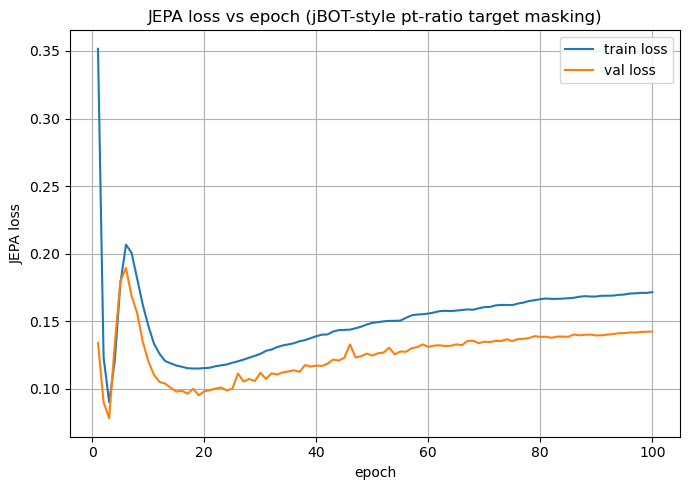

In [9]:
class EpochLossHistory(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_train = []
        self.epoch_val = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epoch_train.append(float(logs.get("loss", np.nan)))
        self.epoch_val.append(float(logs.get("val_loss", np.nan)))

history_cb = EpochLossHistory()

K = 1   

target_mask_train = None
ssl_train = None

for ep in range(EPOCHS):

    if (ep % K == 0) or (target_mask_train is None):
        print(f"[epoch {ep}] resampling train target_mask (jBOT-style pt-ratio masking)")

        target_mask_train = sample_target_mask_pt_ratio(
            tf.convert_to_tensor(x_train, tf.float32),
            p_mask=MASK_PROB,
            ratio_range=MASK_RATIO_RANGE,
        ).numpy().astype(np.float32)

        ssl_train = make_ssl_dataset_quartet(
            part_feats_train,
            pos_train,
            valid_train,
            target_mask_train,
            repeat=False,
            shuffle=True,
        )

    hist = jepa.fit(
        ssl_train,
        validation_data=ssl_val,
        epochs=ep + 1,
        initial_epoch=ep,
        callbacks=[history_cb, lr_sched],
        verbose=1,
    )

epochs_arr = np.arange(1, len(history_cb.epoch_train) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_arr, history_cb.epoch_train, label="train loss")
plt.plot(epochs_arr, history_cb.epoch_val, label="val loss")
plt.xlabel("epoch")
plt.ylabel("JEPA loss")
plt.title("JEPA loss vs epoch (jBOT-style pt-ratio target masking)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
import os

save_dir = "/home/jovyan/qgtrain"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "jepa_teacher.weights.h5")

jepa.teacher.save_weights(save_path)
print("Saved to:", save_path)

Saved to: /home/jovyan/qgtrain/jepa_teacher.weights.h5


In [9]:
import tensorflow as tf

teacher = ParticleEncoder(
    d_model=128,      # must match training
    depth=4,          # must match training
    heads=8,    # use your actual number
    dropout=0.1,
    name="backbone_teacher"
)

# Build once (use correct F=3)
_ = teacher(
    tf.zeros([1, 30, 3], dtype=tf.float32),
    tf.ones([1, 30], dtype=tf.float32),
    training=False
)

teacher.load_weights("/home/jovyan/qgtrain/jepa_teacher.weights.h5")

teacher.trainable = False

d = 128,  N = 100000
top-5 eigenvalues: [5.52462237 4.04537703 3.57272505 2.82325549 2.39667866]
bottom-5:          [ 9.14102239e-03  8.66317381e-03  8.36427586e-03  7.65885641e-03
 -5.11946932e-09]
condition number (lam_max / lam_min): 5524622373434.39
effective rank (exp of entropy of normalized spectrum):
  46.53  /  128  (higher = more isotropic)


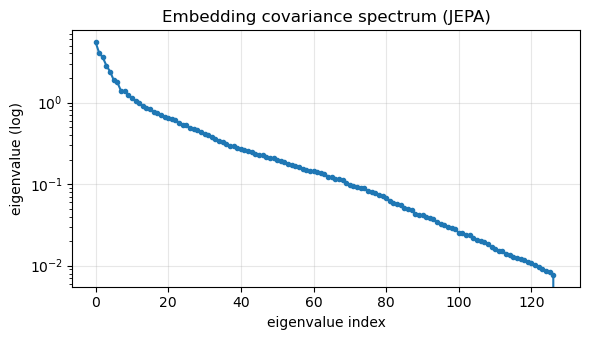

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes `reps_test` (or whatever your downstream eval cell named the pooled test embeddings)
# has been produced by the preceding downstream-eval cell. Adjust the variable name if needed.
try:
    Z = reps_test  # from the downstream eval cell
except NameError:
    Z = get_encoder_reps_meanpool(teacher, part_feats_test, valid_test)

Z = Z - Z.mean(axis=0, keepdims=True)
C = (Z.T @ Z) / Z.shape[0]
evals = np.sort(np.linalg.eigvalsh(C))[::-1]

print(f"d = {Z.shape[1]},  N = {Z.shape[0]}")
print(f"top-5 eigenvalues: {evals[:5]}")
print(f"bottom-5:          {evals[-5:]}")
print(f"condition number (lam_max / lam_min): {evals[0] / max(evals[-1], 1e-12):.2f}")
print(f"effective rank (exp of entropy of normalized spectrum):")
p = evals / evals.sum()
p = p[p > 0]
eff_rank = float(np.exp(-(p * np.log(p)).sum()))
print(f"  {eff_rank:.2f}  /  {Z.shape[1]}  (higher = more isotropic)")

plt.figure(figsize=(6, 3.5))
plt.semilogy(evals, marker='.')
plt.xlabel("eigenvalue index")
plt.ylabel("eigenvalue (log)")
plt.title("Embedding covariance spectrum (JEPA)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

CLASS_NAMES = ['q', 'g', 'W', 'Z', 't']

# --- Balanced test subset indices ---
y_test_int = np.argmax(y_test, axis=-1)
rng = np.random.default_rng(42)
sel_test = np.concatenate([
    rng.choice(np.where(y_test_int == c)[0], size=1000, replace=False)
    for c in range(len(CLASS_NAMES))
]).astype(np.int64)

print("Selected:", len(sel_test), "jets")
print("Class counts:", np.bincount(y_test_int[sel_test]))

Selected: 5000 jets
Class counts: [1000 1000 1000 1000 1000]


In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

# =====================================
# Masked mean pooling utility
# =====================================
def masked_mean(x, mask, axis=1, eps=1e-6):
    m = tf.cast(mask, x.dtype)[..., None]
    return tf.reduce_sum(x * m, axis=axis) / (tf.reduce_sum(m, axis=axis) + eps)

def get_encoder_reps_meanpool(enc, feats, valid, batch_size=1024):
    feats = tf.convert_to_tensor(feats, dtype=tf.float32)
    valid = tf.convert_to_tensor(valid, dtype=tf.float32)
    reps = []
    for i in range(0, int(feats.shape[0]), batch_size):
        z = enc(feats[i:i+batch_size], valid[i:i+batch_size], training=False)
        reps.append(masked_mean(z, valid[i:i+batch_size]).numpy())
    return np.concatenate(reps, axis=0)

# =====================================
# Sanity check: confirm loaded teacher != random init
# =====================================
w_norm = float(tf.norm(teacher.weights[0]))
print(f"teacher first-weight L2 norm: {w_norm:.4f}")
print(f"teacher weights count: {len(teacher.weights)}")

# =====================================
# Extract teacher embeddings (use loaded `teacher`, NOT jepa.teacher)
# =====================================
teacher.trainable = False

Z_train = get_encoder_reps_meanpool(teacher, part_feats_train, valid_train)
Z_val   = get_encoder_reps_meanpool(teacher, part_feats_val,   valid_val)
Z_test  = get_encoder_reps_meanpool(teacher, part_feats_test,  valid_test)

print("Z_train:", Z_train.shape)
print("Z_val:  ", Z_val.shape)
print("Z_test: ", Z_test.shape)

# =====================================
# Balanced subsets
# =====================================
def balanced_indices(y, n_per_class=1000, seed=42):
    y_id = np.argmax(y, axis=1) if y.ndim > 1 else y.astype(np.int64)
    rng  = np.random.default_rng(seed)
    return np.concatenate([
        rng.choice(np.where(y_id == c)[0], size=n_per_class, replace=False)
        for c in np.unique(y_id)
    ]).astype(np.int64)

# y_train 只有 q/g 两类, 所以 sel_train 也只有两类的样本
sel_train = balanced_indices(y_train, n_per_class=1000)
sel_test  = balanced_indices(y_test)   # 5 类 each 1000

y_train_id = np.argmax(y_train, axis=1)
y_test_id  = np.argmax(y_test,  axis=1)

print("Train sel class counts:", np.bincount(y_train_id[sel_train], minlength=5))
print("Test  sel class counts:", np.bincount(y_test_id[sel_test],   minlength=5))

teacher first-weight L2 norm: 3.4090
teacher weights count: 70
Z_train: (250000, 128)
Z_val:   (10000, 128)
Z_test:  (100000, 128)
Train sel class counts: [1000 1000    0    0    0]
Test  sel class counts: [1000 1000 1000 1000 1000]


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

y_train_id = np.argmax(y_train, axis=1)  # only contains 0 (q) and 1 (g)
y_test_id  = np.argmax(y_test,  axis=1)  # contains 0-4

# --- Only use q/g test samples for this 2-class probe ---
qg_mask_test = (y_test_id == 0) | (y_test_id == 1)
Z_test_qg   = Z_test[qg_mask_test]
y_test_qg   = y_test_id[qg_mask_test]

print(f"Train (q+g): {Z_train.shape[0]} samples")
print(f"Test  (q+g): {Z_test_qg.shape[0]} samples "
      f"(q: {(y_test_qg==0).sum()}, g: {(y_test_qg==1).sum()})")

# ====================================
# JEPA teacher: q vs g linear probe
# ====================================
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=5000, solver="lbfgs", random_state=42)
)
clf.fit(Z_train, y_train_id)

print("\n=== JEPA teacher (q vs g) ===")
print("Train acc:", accuracy_score(y_train_id, clf.predict(Z_train)))
print("Test  acc:", accuracy_score(y_test_qg, clf.predict(Z_test_qg)))

# ====================================
# Random encoder baseline
# ====================================
tf.random.set_seed(0)
np.random.seed(0)
rand_enc = ParticleEncoder(d_model=128, depth=4, heads=8, dropout=0.1)
_ = rand_enc(
    tf.zeros([1, 30, 3], tf.float32),
    tf.ones([1, 30], tf.float32),
    training=False
)
rand_enc.trainable = False

Z_rand_train = get_encoder_reps_meanpool(rand_enc, part_feats_train, valid_train)
Z_rand_test  = get_encoder_reps_meanpool(rand_enc, part_feats_test,  valid_test)
Z_rand_test_qg = Z_rand_test[qg_mask_test]

clf_rand = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=5000, solver="lbfgs", random_state=42)
)
clf_rand.fit(Z_rand_train, y_train_id)

print("\n=== Random encoder baseline (q vs g) ===")
print("Test acc:", accuracy_score(y_test_qg, clf_rand.predict(Z_rand_test_qg)))

Train (q+g): 250000 samples
Test  (q+g): 11309 samples (q: 5648, g: 5661)

=== JEPA teacher (q vs g) ===
Train acc: 0.773644
Test  acc: 0.7717746927226103

=== Random encoder baseline (q vs g) ===
Test acc: 0.7578035193208948


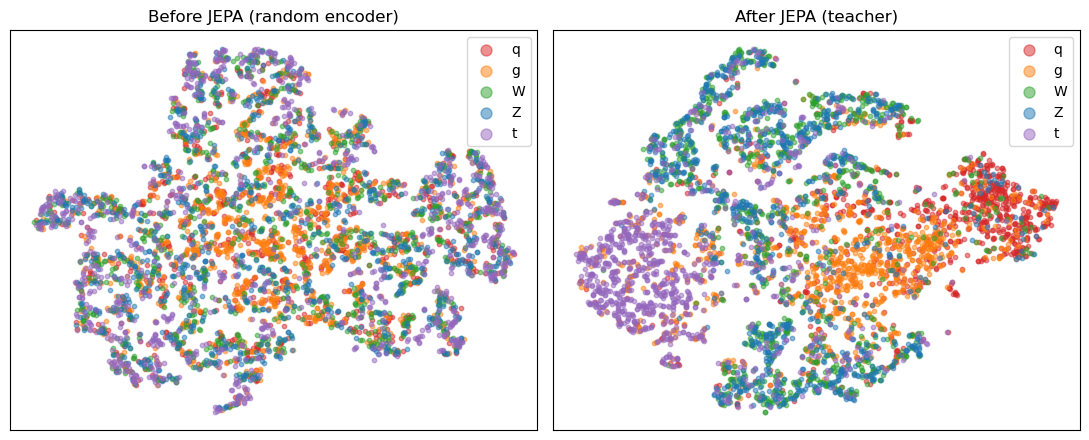

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

names = ["q", "g", "W", "Z", "t"]
class_colors = {'q': 'C3', 'g': 'C1', 'W': 'C2', 'Z': 'C0', 't': 'C4'}

y_sel = np.argmax(y_test, axis=1)[sel_test].astype(np.int64)

def run_tsne(Z):
    Zs = StandardScaler().fit_transform(Z.astype(np.float32))
    Zp = PCA(n_components=min(50, Zs.shape[1]), random_state=42).fit_transform(Zs)
    return TSNE(n_components=2, init="pca", random_state=42).fit_transform(Zp)

Z2_before = run_tsne(Z_rand_test[sel_test])   # random encoder
Z2_after  = run_tsne(Z_test[sel_test])         # trained teacher, same as linear probe

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, Z2_plot, title in zip(axes, [Z2_before, Z2_after],
                               ["Before JEPA (random encoder)", "After JEPA (teacher)"]):
    for k, c in enumerate(names):
        ax.scatter(Z2_plot[y_sel==k, 0], Z2_plot[y_sel==k, 1],
                   s=10, alpha=0.5, color=class_colors[c], label=c)
    ax.set_title(title)
    ax.tick_params(bottom=False, top=False, left=False, right=False,
                   labelbottom=False, labelleft=False)
    ax.legend(markerscale=2.5, loc="upper right")

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt


def l2_normalize(z, axis=1):
    n = np.linalg.norm(z, axis=axis, keepdims=True)
    return z / np.maximum(n, 1e-12)

def knn_distances(z_bank, z_test, l2norm, kmax):
    if l2norm:
        z_bank = l2_normalize(z_bank)
        z_test = l2_normalize(z_test)
    knn = NearestNeighbors(n_neighbors=kmax, metric="euclidean", n_jobs=-1)
    knn.fit(z_bank)
    dists, _ = knn.kneighbors(z_test, return_distance=True)
    return dists  # (N_test, kmax), sorted by increasing distance

def knn_mean_score(dists, k):
    """Anomaly score = mean distance to top-k nearest neighbors in bank."""
    return dists[:, :k].mean(axis=1)

# Config
M_values = [20000, 50000, 100000]
KMAX = 100
k_values = [5, 10, 20, 50, 100]
SEED = 42

# Labels / masks (computed once)
y_test_id = np.argmax(y_test, axis=1)
bkg_mask = (y_test_id == 0) | (y_test_id == 1)
sig_masks = {
    "W":   (y_test_id == 2),
    "Z":   (y_test_id == 3),
    "t":   (y_test_id == 4),
    "all": (y_test_id == 2) | (y_test_id == 3) | (y_test_id == 4),
}

def evaluate_auc(score, bkg_mask, sig_mask):
    m = bkg_mask | sig_mask
    y_bin = sig_mask[m].astype(np.int32)
    return roc_auc_score(y_bin, score[m])


# Sweep over M × metric × k
print(f"Z_train shape: {Z_train.shape}")
print(f"Z_test  shape: {Z_test.shape}")
print()

# Header
print("=" * 90)
print(f"{'M':>7}  {'method':<16} {'k':<6} " +
      " ".join([f"{s:>8}" for s in sig_masks.keys()]))
print("=" * 90)

best = {"auc_all": 0}

for M in M_values:
    # Same seed -> same bank for euclidean and cosine within each M
    rng = np.random.default_rng(SEED)
    bank_idx = rng.choice(Z_train.shape[0], size=M, replace=False)
    z_bank = Z_train[bank_idx]

    # Precompute KNN distances (kmax=100), reuse for all k
    dists_euc = knn_distances(z_bank, Z_test, l2norm=False, kmax=KMAX)
    dists_cos = knn_distances(z_bank, Z_test, l2norm=True,  kmax=KMAX)

    for method_name, dists in [("knn-euclidean", dists_euc),
                                ("knn-cosine",    dists_cos)]:
        for k in k_values:
            score = knn_mean_score(dists, k=k)
            aucs = {sig: evaluate_auc(score, bkg_mask, m)
                    for sig, m in sig_masks.items()}
            print(f"{M:>7}  {method_name:<16} k={k:<4} " +
                  " ".join([f"{aucs[s]:>8.4f}" for s in sig_masks.keys()]))

            if aucs["all"] > best["auc_all"]:
                best = {
                    "M": M,
                    "metric": method_name,
                    "k": k,
                    "auc_all": aucs["all"],
                    "aucs": aucs,
                    "score": score,
                    "bank_idx": bank_idx,
                    "l2norm": (method_name == "knn-cosine"),
                }
    print("-" * 90)

print("=" * 90)
print(f"\nBest config: M={best['M']}, {best['metric']}, k={best['k']}, "
      f"AUC(all)={best['auc_all']:.4f}")
print(f"  W={best['aucs']['W']:.4f}  Z={best['aucs']['Z']:.4f}  t={best['aucs']['t']:.4f}")

Z_train shape: (250000, 128)
Z_test  shape: (100000, 128)

      M  method           k             W        Z        t      all
  20000  knn-euclidean    k=5      0.7097   0.7255   0.8508   0.7624
  20000  knn-euclidean    k=10     0.7329   0.7514   0.8647   0.7835
  20000  knn-euclidean    k=20     0.7544   0.7750   0.8762   0.8022
  20000  knn-euclidean    k=50     0.7779   0.7993   0.8863   0.8215
  20000  knn-euclidean    k=100    0.7916   0.8126   0.8882   0.8311
  20000  knn-cosine       k=5      0.7075   0.7270   0.8755   0.7705
  20000  knn-cosine       k=10     0.7242   0.7459   0.8861   0.7859
  20000  knn-cosine       k=20     0.7396   0.7634   0.8956   0.8000
  20000  knn-cosine       k=50     0.7565   0.7822   0.9056   0.8152
  20000  knn-cosine       k=100    0.7661   0.7927   0.9096   0.8233
------------------------------------------------------------------------------------------
  50000  knn-euclidean    k=5      0.6860   0.7014   0.8384   0.7424
  50000  knn-euclidean

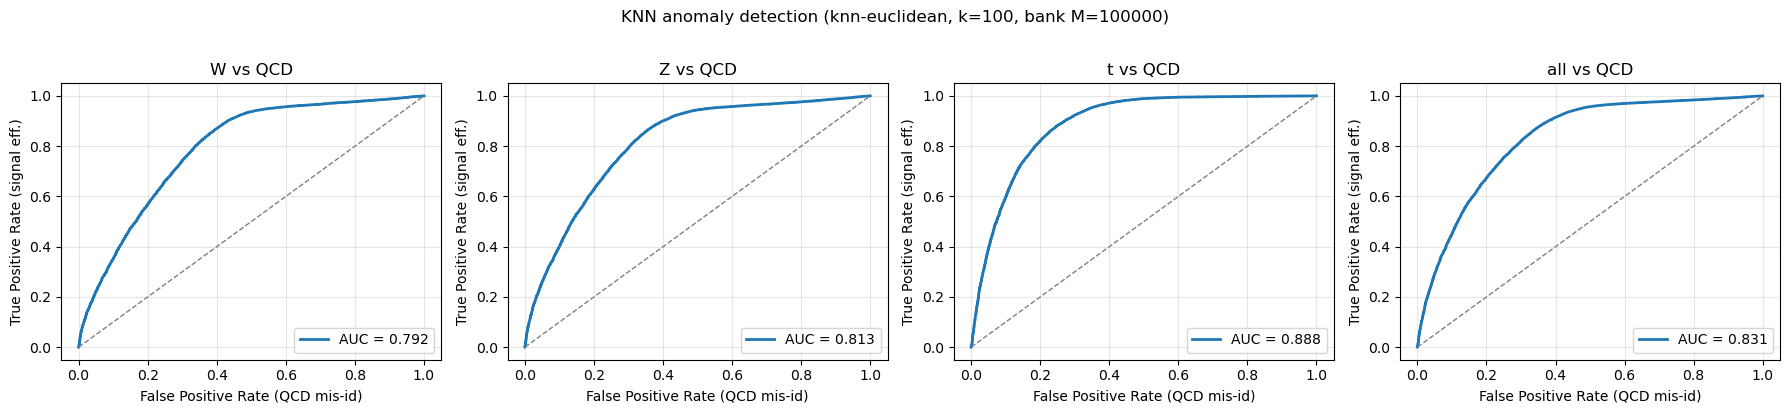

In [17]:
# Plot ROC curves for the best config
score = best["score"]

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
for ax, (sig_name, sig_mask) in zip(axs, sig_masks.items()):
    m = bkg_mask | sig_mask
    y_bin = sig_mask[m].astype(np.int32)
    s = score[m]
    fpr, tpr, _ = roc_curve(y_bin, s)
    aucv = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {aucv:.3f}")
    ax.plot([0,1], [0,1], '--', color='gray', lw=1)
    ax.set_xlabel("False Positive Rate (QCD mis-id)")
    ax.set_ylabel("True Positive Rate (signal eff.)")
    ax.set_title(f"{sig_name} vs QCD")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.suptitle(f"KNN anomaly detection ({best['metric']}, k={best['k']}, bank M={M})",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

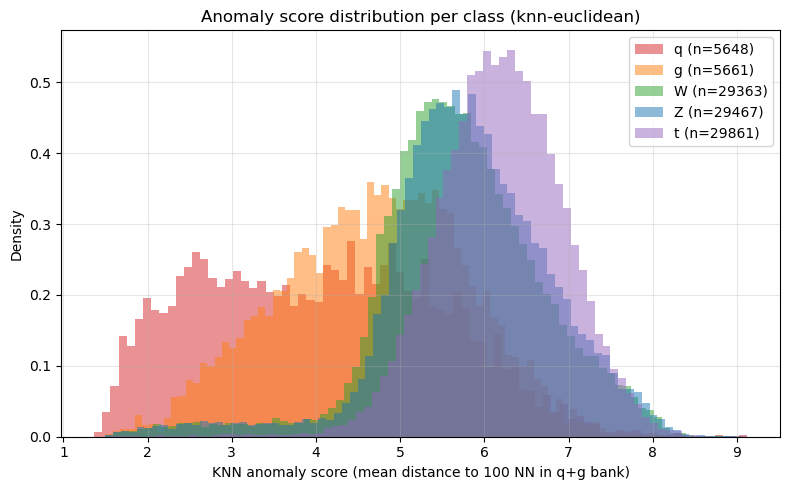

In [18]:
# Plot anomaly score histograms per class
score = best["score"]

class_names = ['q', 'g', 'W', 'Z', 't']
class_colors = {'q': 'C3', 'g': 'C1', 'W': 'C2', 'Z': 'C0', 't': 'C4'}

plt.figure(figsize=(8, 5))
for c, name in enumerate(class_names):
    mask = (y_test_id == c)
    plt.hist(score[mask], bins=80, alpha=0.5, density=True,
             label=f"{name} (n={mask.sum()})", color=class_colors[name])

plt.xlabel(f"KNN anomaly score (mean distance to {best['k']} NN in q+g bank)")
plt.ylabel("Density")
plt.title(f"Anomaly score distribution per class ({best['metric']})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# # ==========================================
# # 1) Frozen token extraction from teacher
# # ==========================================
# def get_token_reps(teacher_enc, feats, valid, batch_size=1024):
#     """
#     teacher_enc(feats, valid, training=False) -> token reps (B, N, D)

#     feats: (B, N, F)
#     valid: (B, N)
#     returns:
#         token reps: (B, N, D)
#         masks:      (B, N)
#     """
#     feats = tf.convert_to_tensor(feats, dtype=tf.float32)
#     valid = tf.convert_to_tensor(valid, dtype=tf.float32)

#     reps = []
#     masks = []
#     n = int(feats.shape[0])

#     for i in range(0, n, batch_size):
#         f = feats[i:i + batch_size]
#         v = valid[i:i + batch_size]

#         z = teacher_enc(f, v, training=False)   # (b, N, D)
#         reps.append(z.numpy())
#         masks.append(v.numpy())

#     return np.concatenate(reps, axis=0), np.concatenate(masks, axis=0)


# # ==========================================
# # 2) Attention pooling layer
# # ==========================================
# class MaskedAttentionPool(layers.Layer):
#     def __init__(self, hidden_dim=128, **kwargs):
#         super().__init__(**kwargs)
#         self.score_net = keras.Sequential([
#             layers.Dense(hidden_dim, activation="gelu"),
#             layers.Dense(1),
#         ])

#     def call(self, z, valid):
#         """
#         z:     (B, N, D)
#         valid: (B, N)
#         returns:
#             pooled: (B, D)
#             attn:   (B, N)
#         """
#         logits = self.score_net(z)[:, :, 0]   # (B, N)

#         mask = tf.cast(valid, z.dtype)
#         neg = tf.constant(-1e9, dtype=z.dtype)
#         logits = tf.where(mask > 0, logits, neg)

#         attn = tf.nn.softmax(logits, axis=1)                 # (B, N)
#         pooled = tf.reduce_sum(z * attn[..., None], axis=1)  # (B, D)
#         return pooled, attn


# # ==========================================
# # 3) Probe on frozen token embeddings
# # ==========================================
# class FrozenAttentionProbe(keras.Model):
#     def __init__(self, num_classes, attn_hidden=128, use_layernorm=True):
#         super().__init__()
#         self.pool = MaskedAttentionPool(hidden_dim=attn_hidden)
#         self.use_layernorm = use_layernorm

#         if use_layernorm:
#             self.norm = layers.LayerNormalization(epsilon=1e-6)

#         self.head = layers.Dense(num_classes)   # logits

#     def call(self, inputs, training=False, return_pooled=False):
#         z, valid = inputs
#         pooled, attn = self.pool(z, valid)

#         if self.use_layernorm:
#             pooled = self.norm(pooled, training=training)

#         logits = self.head(pooled)

#         if return_pooled:
#             return logits, pooled, attn
#         return logits


# # ==========================================
# # 4) Helper: extract attention-pooled reps
# # ==========================================
# def get_attention_pooled_reps(probe_attn, token_reps, masks, batch_size=1024):
#     """
#     Use the TRAINED attention probe's pooling module to extract pooled embeddings.

#     token_reps: (B, N, D)
#     masks:      (B, N)
#     returns:
#         pooled reps: (B, D)
#     """
#     token_reps = tf.convert_to_tensor(token_reps, dtype=tf.float32)
#     masks      = tf.convert_to_tensor(masks, dtype=tf.float32)

#     out = []
#     n = int(token_reps.shape[0])

#     for i in range(0, n, batch_size):
#         z = token_reps[i:i + batch_size]
#         v = masks[i:i + batch_size]

#         _, pooled, _ = probe_attn((z, v), training=False, return_pooled=True)
#         out.append(pooled.numpy())

#     return np.concatenate(out, axis=0)


# # ==========================================
# # 5) Optional sanity checks
# # ==========================================
# def sanity_check_tokens_and_masks(T, M, name="train"):
#     print(f"{name} token reps shape:", T.shape)
#     print(f"{name} mask shape:", M.shape)
#     print(f"{name} token mean:", float(np.mean(T)))
#     print(f"{name} token std :", float(np.std(T)))
#     print(f"{name} valid unique:", np.unique(M))


# # ==========================================
# # 6) Extract frozen tokens from teacher
# # ==========================================
# teacher_enc = teacher
# teacher_enc.trainable = False

# T_train, M_train = get_token_reps(
#     teacher_enc, part_feats_train, valid_train, batch_size=1024
# )
# T_val, M_val = get_token_reps(
#     teacher_enc, part_feats_val, valid_val, batch_size=1024
# )
# T_test, M_test = get_token_reps(
#     teacher_enc, part_feats_test, valid_test, batch_size=1024
# )

# sanity_check_tokens_and_masks(T_train, M_train, name="train")
# sanity_check_tokens_and_masks(T_val,   M_val,   name="val")
# sanity_check_tokens_and_masks(T_test,  M_test,  name="test")


# # ==========================================
# # 7) Labels
# # ==========================================
# if y_train.ndim > 1:
#     y_train_id = np.argmax(y_train, axis=1)
#     y_val_id   = np.argmax(y_val, axis=1)
#     y_test_id  = np.argmax(y_test, axis=1)
# else:
#     y_train_id = y_train.astype(np.int64)
#     y_val_id   = y_val.astype(np.int64)
#     y_test_id  = y_test.astype(np.int64)

# num_classes = len(np.unique(y_train_id))


# # ==========================================
# # 8) Train attention probe
# # ==========================================
# probe_attn = FrozenAttentionProbe(
#     num_classes=num_classes,
#     attn_hidden=128,
#     use_layernorm=True,
# )

# # build once
# _ = probe_attn(
#     (
#         tf.zeros((1, T_train.shape[1], T_train.shape[2]), dtype=tf.float32),
#         tf.ones((1, T_train.shape[1]), dtype=tf.float32),
#     ),
#     training=False
# )

# probe_attn.compile(
#     optimizer=keras.optimizers.Adam(1e-3),
#     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=["accuracy"],
# )

# callbacks = [
#     keras.callbacks.EarlyStopping(
#         monitor="val_accuracy",
#         patience=8,
#         restore_best_weights=True,
#     )
# ]

# hist = probe_attn.fit(
#     (T_train, M_train), y_train_id,
#     validation_data=((T_val, M_val), y_val_id),
#     epochs=100,
#     batch_size=1024,
#     callbacks=callbacks,
#     verbose=2,
# )

# # Explicit final eval
# val_loss, val_acc = probe_attn.evaluate((T_val, M_val), y_val_id, verbose=0)
# test_loss, test_acc = probe_attn.evaluate((T_test, M_test), y_test_id, verbose=0)

# print("\nAttention Probe results")
# print("Attention Probe val acc: ", val_acc)
# print("Attention Probe test acc:", test_acc)


# # ==========================================
# # 9) Export attention-pooled embeddings
# # ==========================================
# Z_attn_train = get_attention_pooled_reps(
#     probe_attn, T_train, M_train, batch_size=1024
# )
# Z_attn_val = get_attention_pooled_reps(
#     probe_attn, T_val, M_val, batch_size=1024
# )
# Z_attn_test = get_attention_pooled_reps(
#     probe_attn, T_test, M_test, batch_size=1024
# )

# print("Z_attn_train:", Z_attn_train.shape)
# print("Z_attn_val:  ", Z_attn_val.shape)
# print("Z_attn_test: ", Z_attn_test.shape)

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# import numpy as np

# # =====================================
# # Logistic regression on attention-pooled embeddings
# # =====================================

# # labels -> integer ids
# if y_train.ndim > 1:
#     y_id_train = np.argmax(y_train, axis=1)
# else:
#     y_id_train = y_train.astype(np.int64)

# if y_val.ndim > 1:
#     y_id_val = np.argmax(y_val, axis=1)
# else:
#     y_id_val = y_val.astype(np.int64)

# if y_test.ndim > 1:
#     y_id_test = np.argmax(y_test, axis=1)
# else:
#     y_id_test = y_test.astype(np.int64)

# # logistic regression classifier on Z_attn_*
# clf_attn = LogisticRegression(
#     C=1.0,
#     max_iter=5000,
#     solver="lbfgs",
#     multi_class="multinomial",
#     n_jobs=-1,
#     random_state=42,
# )

# clf_attn.fit(Z_attn_train, y_id_train)

# pred_train = clf_attn.predict(Z_attn_train)
# pred_val   = clf_attn.predict(Z_attn_val)
# pred_test  = clf_attn.predict(Z_attn_test)

# print("AttnPool Logistic train acc:", accuracy_score(y_id_train, pred_train))
# print("AttnPool Logistic val acc:  ", accuracy_score(y_id_val, pred_val))
# print("AttnPool Logistic test acc: ", accuracy_score(y_id_test, pred_test))

In [ ]:
# import numpy as np
# import tensorflow as tf

# def get_attention_pooled_reps(probe_attn, T, M, batch_size=1024):
#     """
#     probe_attn: trained FrozenAttentionProbe
#     T: token reps (N, P, D)
#     M: valid masks (N, P)
#     returns pooled reps (N, D)
#     """
#     T = tf.convert_to_tensor(T, tf.float32)
#     M = tf.convert_to_tensor(M, tf.float32)

#     outs = []
#     n = int(T.shape[0])

#     for i in range(0, n, batch_size):
#         tb = T[i:i+batch_size]
#         mb = M[i:i+batch_size]

#         pooled = probe_attn.pool(tb, mb)
#         if probe_attn.use_layernorm:
#             pooled = probe_attn.norm(pooled, training=False)

#         outs.append(pooled.numpy())

#     return np.concatenate(outs, axis=0)

# Zattn_train = get_attention_pooled_reps(probe_attn, T_train, M_train, batch_size=1024)
# Zattn_val   = get_attention_pooled_reps(probe_attn, T_val,   M_val,   batch_size=1024)
# Zattn_test  = get_attention_pooled_reps(probe_attn, T_test,  M_test,  batch_size=1024)

# print(Zattn_train.shape, Zattn_val.shape, Zattn_test.shape)



In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # choose ONE split explicitly
# Z_all = Zattn_test
# y_all = y_test
# sel = sel_test

# names = ["q", "g", "W", "Z", "t"]

# if y_all.ndim == 2:
#     y_id_all = np.argmax(y_all, axis=1).astype(np.int64)
# else:
#     y_id_all = y_all.astype(np.int64)

# sel = np.asarray(sel, dtype=np.int64)

# Z = Z_all[sel]
# y = y_id_all[sel]

# print("Selected subset:", Z.shape, y.shape)
# print("Class counts:", {c: int(np.sum(y == c)) for c in range(5)})

# n_pca = min(50, Z.shape[1], Z.shape[0])
# Z50 = PCA(n_components=n_pca, random_state=42).fit_transform(Z)

# tsne = TSNE(
#     n_components=2,
#     perplexity=30,
#     init="pca",
#     learning_rate="auto",
#     random_state=42,
# )
# Z2 = tsne.fit_transform(Z50)

# plt.figure(figsize=(7, 6))
# for c, name in enumerate(names):
#     m = (y == c)
#     if np.any(m):
#         plt.scatter(Z2[m, 0], Z2[m, 1], s=8, alpha=0.7, label=name)

# plt.title("t-SNE of attention-pooled JEPA representations (test subset)")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend(markerscale=2)
# plt.tight_layout()
# plt.show()

In [ ]:
target_mask_check = sample_target_mask_pt_ratio(
    tf.convert_to_tensor(x_train, tf.float32),
    p_mask=MASK_PROB,
    ratio_range=MASK_RATIO_RANGE,
).numpy().astype(np.float32)

frac_train = masked_pt_fraction(
    x_train[..., 2],
    x_train[..., 3],
    target_mask_check
)

summarize(frac_train, "TRAIN (jBOT-style pt-ratio sanity check)")

In [ ]:
# import numpy as np
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# names = ["q", "g", "W", "Z", "t"]

# def to_ids(y):
#     y = np.asarray(y)
#     if y.ndim == 2:
#         return np.argmax(y, axis=1).astype(np.int64)
#     return y.astype(np.int64)

# y_train_id_all = to_ids(y_train)
# y_val_id_all   = to_ids(y_val)

# # use split-matched selections
# Xtr = Z_train[sel_train]
# ytr = y_train_id_all[sel_train]

# Xva = Z_val[sel_val]
# yva = y_val_id_all[sel_val]

# print("Train subset:", Xtr.shape, ytr.shape, " Val subset:", Xva.shape, yva.shape)
# print("Train class counts:", {c: int(np.sum(ytr == c)) for c in range(5)})
# print("Val class counts  :", {c: int(np.sum(yva == c)) for c in range(5)})

# k_list = [1, 3, 5, 10, 20, 50, 100]
# metric = "cosine"

# results = []
# best = None

# for k in k_list:
#     knn = KNeighborsClassifier(
#         n_neighbors=k,
#         weights="distance",
#         metric=metric,
#         n_jobs=-1
#     )
#     knn.fit(Xtr, ytr)
#     pred = knn.predict(Xva)

#     acc = accuracy_score(yva, pred)
#     f1m = f1_score(yva, pred, average="macro")

#     results.append((k, acc, f1m))
#     if best is None or f1m > best[2]:
#         best = (k, acc, f1m, pred)

# print(f"\nKNN results (metric={metric}, weights=distance)")
# for k, acc, f1m in results:
#     print(f"  k={k:>3d}  acc={acc:.4f}  macroF1={f1m:.4f}")

# best_k, best_acc, best_f1m, best_pred = best
# print(f"\nBest k={best_k}  acc={best_acc:.4f}  macroF1={best_f1m:.4f}")

# cm = confusion_matrix(yva, best_pred, labels=[0,1,2,3,4])
# print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

# print("\nClassification report:")
# print(classification_report(yva, best_pred, target_names=names, digits=4))